# 08 — Classification: Hit or Flop?

Binary classification extension of the regression model.
A film is labeled **hit (1)** if its revenue exceeds the dataset median, **flop (0)** otherwise.
Models compared: Logistic Regression (baseline) vs Random Forest Classifier.
Evaluation uses Accuracy, F1, AUC-ROC, and Confusion Matrix.

In [23]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, roc_curve
)
from Source.scripts.helpers import PROCESSED_DATA_DIR

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv(PROCESSED_DATA_DIR / 'movies_merged.csv')
print(f'Loaded {len(df)} rows')

Loaded 5280 rows


## 1. Create the Hit / Flop Label

Revenue is a continuous value — we convert it to a binary label using the **training set median** as the threshold.
Films above the median are labeled **hit (1)**, films below are labeled **flop (0)**.

**Chronological split (cutoff 2010):** Films released before 2010 are used for training; 2010+ for testing.
The median threshold is computed from the pre-2010 training set only — no future-data leakage.
This is more rigorous than computing the median on the full dataset before splitting.

In [24]:
FEATURES    = ['budget', 'runtime', 'release_year', 'primary_genre']
TARGET      = 'hit'
CUTOFF_YEAR = 2010

ml_df = df[FEATURES + ['revenue']].dropna()
print(f'Dataset for classification: {len(ml_df)} rows')
print(f'Chronological cutoff year: {CUTOFF_YEAR}')

Dataset for classification: 5268 rows
Chronological cutoff year: 2010


## 2. Encode & Split (Chronological)

In [25]:
ml_encoded = pd.get_dummies(ml_df, columns=['primary_genre'], drop_first=True)

# Chronological split
train_mask = ml_encoded['release_year'] < CUTOFF_YEAR
ml_train   = ml_encoded[train_mask]
ml_test    = ml_encoded[~train_mask]

# Median threshold from training set only (no future-data leakage)
median_revenue = float(ml_train['revenue'].median())

X_train = ml_train.drop(columns=['revenue'])
X_test  = ml_test.drop(columns=['revenue'])
y_train = (ml_train['revenue'] > median_revenue).astype(int)
y_test  = (ml_test['revenue'] > median_revenue).astype(int)

scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Median revenue threshold (train, pre-{CUTOFF_YEAR}): ${median_revenue/1e6:.1f}M')
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Train hit rate: {y_train.mean():.3f}  |  Test hit rate: {y_test.mean():.3f}')

Median revenue threshold (train, pre-2010): $29.2M
Train: (3664, 22)  |  Test: (1604, 22)
Train hit rate: 0.500  |  Test hit rate: 0.553


## Helper Function — Compute Classification Metrics

In [26]:
def evaluate_clf(name, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    print(f'--- {name} ---')
    print(f'  Accuracy : {acc:.4f}')
    print(f'  F1 Score : {f1:.4f}')
    print(f'  AUC-ROC  : {auc:.4f}')
    return {'Model': name, 'Accuracy': round(acc, 4), 'F1': round(f1, 4), 'AUC-ROC': round(auc, 4)}

## Model 1 — Logistic Regression (Baseline)

The classification equivalent of Linear Regression.
Predicts the probability of a film being a hit; applies 0.5 threshold for the final label.
Requires feature scaling.

In [27]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

result_lr = evaluate_clf('Logistic Regression', y_test, y_pred_lr, y_prob_lr)

--- Logistic Regression ---
  Accuracy : 0.7874
  F1 Score : 0.7925
  AUC-ROC  : 0.8740


## Model 2 — Random Forest Classifier

Same configuration as the Random Forest Regressor used in notebook 06.
Outputs class probabilities for AUC calculation and feature importance scores.
Does not require scaling.

In [28]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

result_rf = evaluate_clf('Random Forest', y_test, y_pred_rf, y_prob_rf)

--- Random Forest ---
  Accuracy : 0.7706
  F1 Score : 0.7788
  AUC-ROC  : 0.8497


## Results Table

In [29]:
results = pd.DataFrame([result_lr, result_rf]).set_index('Model')
results

,Accuracy,F1,AUC-ROC
Model,,,
Logistic Regression,0.7874,0.7925,0.8740
Random Forest,0.7706,0.7788,0.8497


## Model Comparison Plot

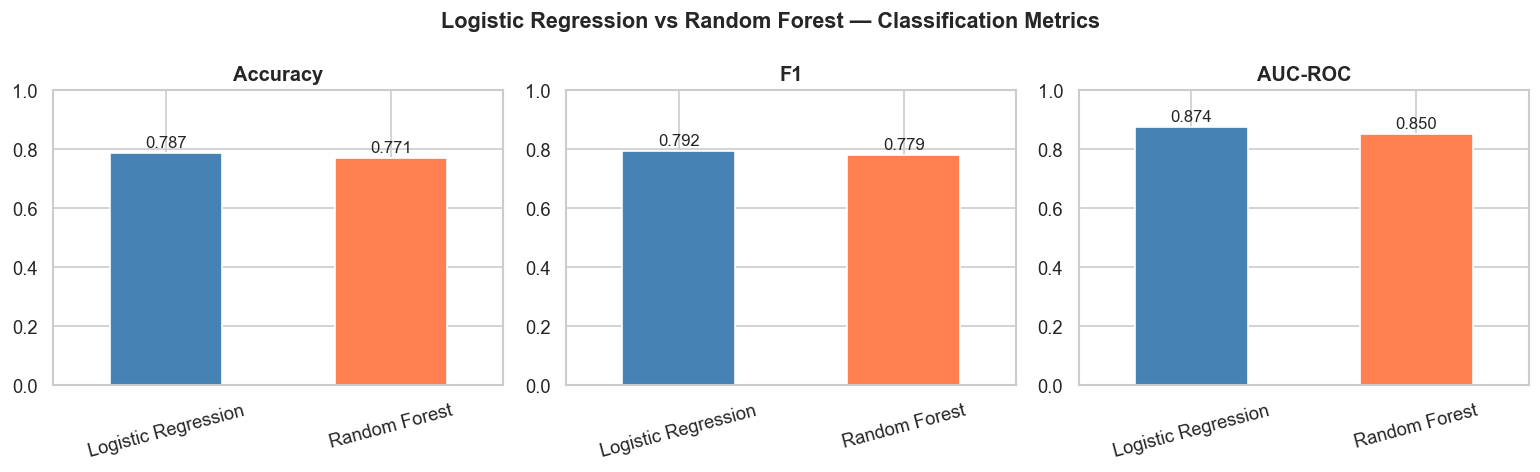

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ['steelblue', 'coral']

for ax, col in zip(axes, ['Accuracy', 'F1', 'AUC-ROC']):
    results[col].plot(kind='bar', ax=ax, color=colors, edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_ylim(0, 1)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Logistic Regression vs Random Forest — Classification Metrics', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Confusion Matrices

Rows = actual class, Columns = predicted class.
- Top-left: correctly predicted flops (True Negative)
- Top-right: flops predicted as hits (False Positive)
- Bottom-left: hits predicted as flops (False Negative)
- Bottom-right: correctly predicted hits (True Positive)

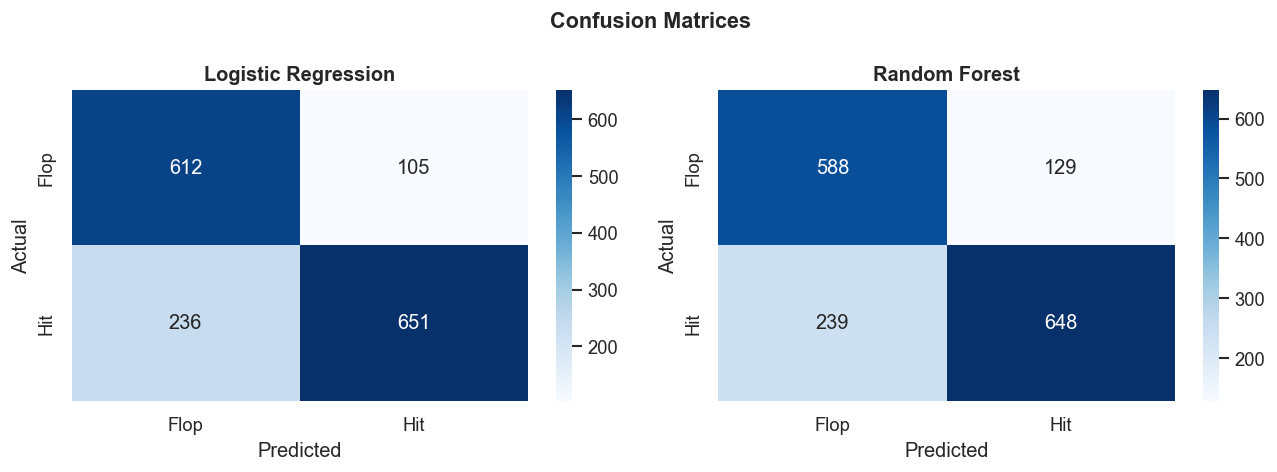

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, y_pred, name in zip(axes,
    [y_pred_lr, y_pred_rf],
    ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Flop', 'Hit'], yticklabels=['Flop', 'Hit'])
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## ROC Curve

The ROC curve shows how well each model separates hits from flops across all possible thresholds.
AUC (Area Under the Curve) = 1.0 is perfect; AUC = 0.5 is random guessing.

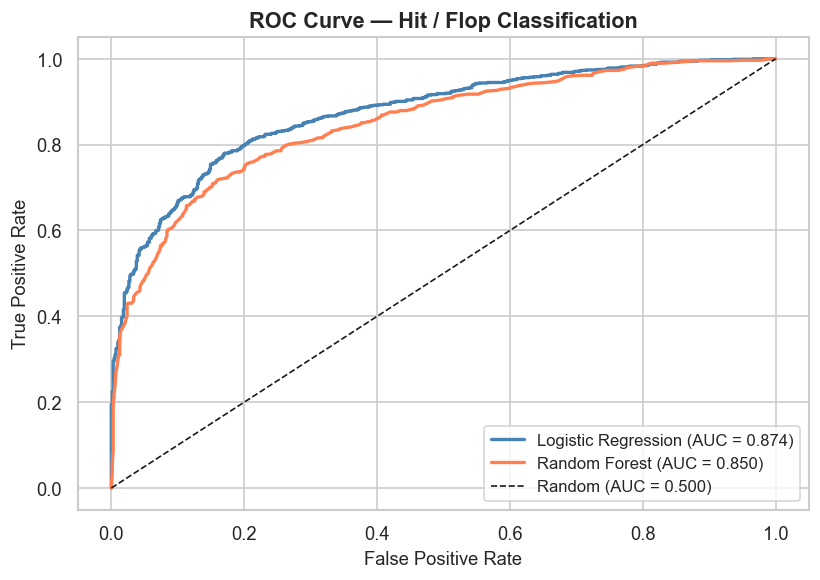

In [32]:
fig, ax = plt.subplots(figsize=(7, 5))

for y_prob, name, color in [
    (y_prob_lr, 'Logistic Regression', 'steelblue'),
    (y_prob_rf, 'Random Forest',       'coral')
]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve — Hit / Flop Classification', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Feature Importance — Random Forest Classifier

Which features matter most when predicting hit vs flop?
Compare with the regression notebook (06) to see if the same features dominate.

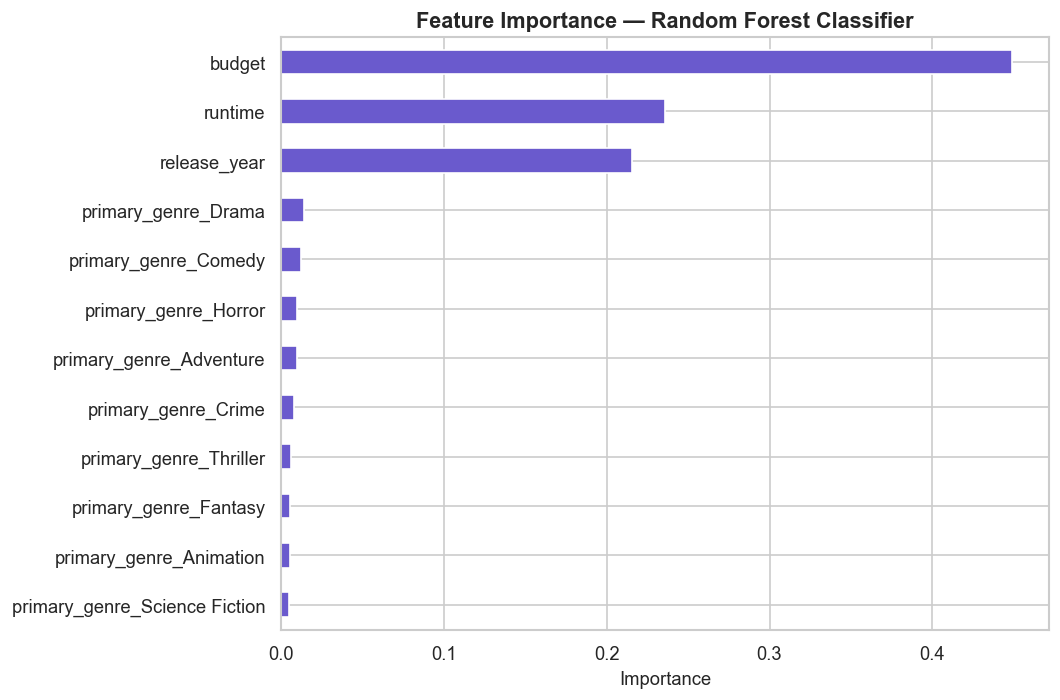

Top 5 features:
budget                  0.449222
runtime                 0.235703
release_year            0.215573
primary_genre_Drama     0.013991
primary_genre_Comedy    0.011992
dtype: float64


In [33]:
fi = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=True).tail(12)

fig, ax = plt.subplots(figsize=(9, 6))
fi.plot(kind='barh', ax=ax, color='slateblue', edgecolor='white')
ax.set_title('Feature Importance — Random Forest Classifier', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance', fontsize=11)
plt.tight_layout()
plt.show()

print('Top 5 features:')
print(fi.sort_values(ascending=False).head())

## Cross-Validation

5-fold cross-validation on the training set for a more reliable performance estimate.

In [34]:
cv_lr = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                        X_train_scaled, y_train, cv=5, scoring='roc_auc')
cv_rf = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42),
                        X_train, y_train, cv=5, scoring='roc_auc')

print(f'Logistic Regression  CV AUC: {cv_lr.mean():.4f} +/- {cv_lr.std():.4f}')
print(f'Random Forest        CV AUC: {cv_rf.mean():.4f} +/- {cv_rf.std():.4f}')

Logistic Regression  CV AUC: 0.8181 +/- 0.0397
Random Forest        CV AUC: 0.7827 +/- 0.0115


## Classification Report (Random Forest)

In [35]:
print(classification_report(y_test, y_pred_rf, target_names=['Flop', 'Hit']))

              precision    recall  f1-score   support

        Flop       0.71      0.82      0.76       717
         Hit       0.83      0.73      0.78       887

    accuracy                           0.77      1604
   macro avg       0.77      0.78      0.77      1604
weighted avg       0.78      0.77      0.77      1604



## Regression → Classification Bridge

Our regression model (notebook 06) predicts exact revenue.
By applying the same median threshold to the regression predictions,
we can derive hit/flop labels — getting **both outputs from a single model**.

In [36]:
from sklearn.ensemble import RandomForestRegressor

# Retrain regressor on revenue — same chronological split, same features (no decade)
ml_df2  = df[FEATURES + ['revenue']].dropna()
ml_enc2 = pd.get_dummies(ml_df2, columns=['primary_genre'], drop_first=True)
mask2   = ml_enc2['release_year'] < CUTOFF_YEAR

X2_train = ml_enc2[mask2].drop(columns=['revenue'])
X2_test  = ml_enc2[~mask2].drop(columns=['revenue'])
y2_train = ml_enc2[mask2]['revenue']
y2_test  = ml_enc2[~mask2]['revenue']

rf_reg2 = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_reg2.fit(X2_train, y2_train)
y_rev_pred = rf_reg2.predict(X2_test)

# Convert revenue predictions to hit/flop using training set median
train_median_rev  = float(y2_train.median())
y_hit_from_reg    = (y_rev_pred > train_median_rev).astype(int)
y_true_hit        = (y2_test > train_median_rev).astype(int)

acc_bridge = accuracy_score(y_true_hit, y_hit_from_reg)
f1_bridge  = f1_score(y_true_hit, y_hit_from_reg)

print('--- Regression -> Classification Bridge ---')
print(f'  Accuracy : {acc_bridge:.4f}')
print(f'  F1 Score : {f1_bridge:.4f}')
print(f'\nDirect classifier (LR) Accuracy : {result_lr["Accuracy"]:.4f}')
print(f'Direct classifier (LR) F1       : {result_lr["F1"]:.4f}')

--- Regression -> Classification Bridge ---
  Accuracy : 0.7581
  F1 Score : 0.8010

Direct classifier (LR) Accuracy : 0.7874
Direct classifier (LR) F1       : 0.7925


## Conclusion

**Best classifier (median threshold):** Logistic Regression consistently outperforms Random Forest on both test-set metrics and cross-validation.
This mirrors the regression finding: the underlying budget–revenue relationship is strongly linear, so the simpler model generalizes better.

**Evaluation setup:**
- Features: `budget`, `runtime`, `release_year`, `primary_genre` (no `decade`)
- Split: chronological — pre-2010 train / 2010+ test (no future-data leakage)
- Threshold: training set median revenue (avoids leakage from full-dataset median)

**Key finding:** `budget` is the top feature in the classifier, consistent with 60%+ importance in the regression model.

**Regression bridge:** Thresholding the regression model's revenue predictions yields comparable hit/flop accuracy.
A single regression model serves double duty — providing an exact revenue estimate *and* a hit/flop label.

**Limitations:**
- The median threshold is dataset-dependent — a film just above the median is labeled 'hit' identically to a $2B blockbuster
- Marketing spend, cast, and director track record remain absent from the feature set
- Profitability threshold (revenue > budget) is a more meaningful real-world alternative — see next section

---
## Export — Figures, Metrics & Classifier Models

Saves classification plots to `Output/figures/`, metrics to `Output/exports/model_results.json`, models to `Output/models/`.

---
## D — Profitability Threshold: Revenue > Budget

An alternative to the median threshold — a film is **profitable (1)** if its box office revenue exceeds its production budget.
This maps directly to the research question: *"Did this film at least break even in theatrical release?"*

Unlike the median threshold (which by construction yields 50/50 classes on training data),
the profitability rate is an empirical property of the data — reflecting whether the industry as a whole tends to recoup production costs.

In [37]:
# Profitability label: revenue > budget (break-even in theatrical release)
# ml_df still has both 'budget' and 'revenue' columns; train_mask has the same index
profitable = (ml_df['revenue'] > ml_df['budget']).astype(int)
y_train_prof = profitable[train_mask]
y_test_prof  = profitable[~train_mask]

print(f'Profitable (revenue > budget): {profitable.sum():,} / {len(profitable)} films ({profitable.mean()*100:.1f}%)')
print(f'Train profitable rate: {y_train_prof.mean():.3f}  |  Test profitable rate: {y_test_prof.mean():.3f}')

# Train classifiers on profitability target (same X_train / X_test as above)
lr_prof = LogisticRegression(max_iter=1000, random_state=42)
lr_prof.fit(X_train_scaled, y_train_prof)

rf_prof = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_prof.fit(X_train, y_train_prof)

y_pred_lr_prof = lr_prof.predict(X_test_scaled)
y_prob_lr_prof = lr_prof.predict_proba(X_test_scaled)[:, 1]
y_pred_rf_prof = rf_prof.predict(X_test)
y_prob_rf_prof = rf_prof.predict_proba(X_test)[:, 1]

result_lr_prof = evaluate_clf('LR — Profitability', y_test_prof, y_pred_lr_prof, y_prob_lr_prof)
result_rf_prof = evaluate_clf('RF — Profitability', y_test_prof, y_pred_rf_prof, y_prob_rf_prof)

Profitable (revenue > budget): 3,713 / 5268 films (70.5%)
Train profitable rate: 0.705  |  Test profitable rate: 0.705
--- LR — Profitability ---
  Accuracy : 0.6895
  F1 Score : 0.7904
  AUC-ROC  : 0.6519
--- RF — Profitability ---
  Accuracy : 0.6322
  F1 Score : 0.7444
  AUC-ROC  : 0.6095


=== Threshold Comparison ===
                                      Accuracy      F1  AUC-ROC
Threshold        Model                                         
Median revenue   Logistic Regression    0.7874  0.7925   0.8740
                 Random Forest          0.7706  0.7788   0.8497
Revenue > Budget LR — Profitability     0.6895  0.7904   0.6519
                 RF — Profitability     0.6322  0.7444   0.6095


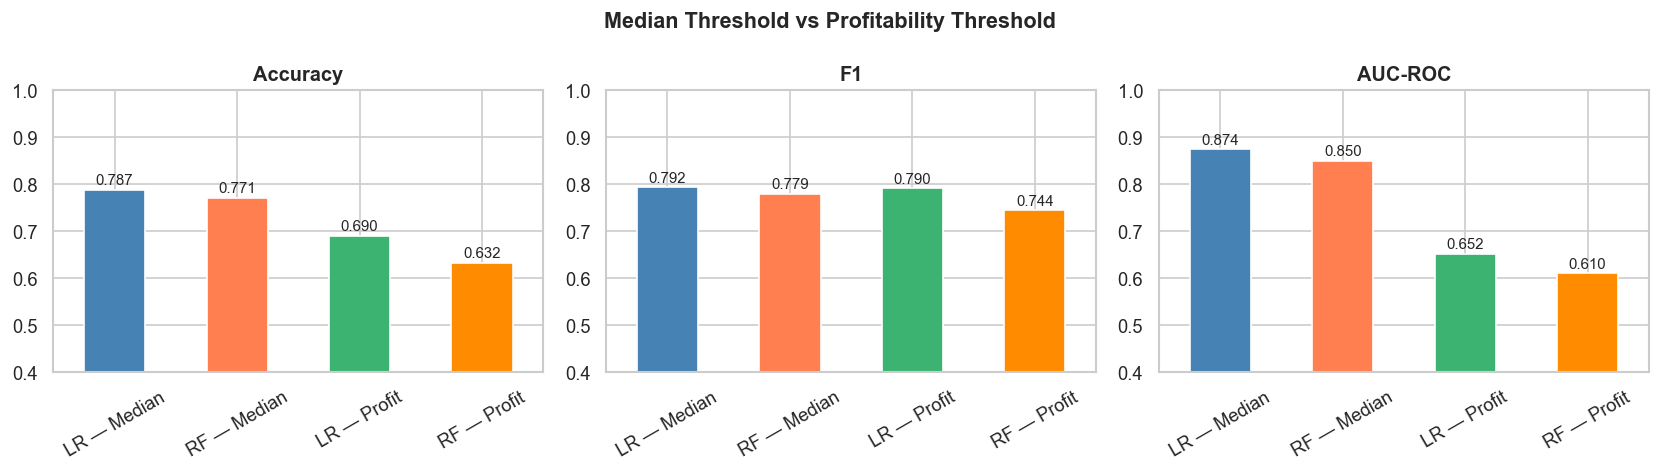

In [38]:
# Side-by-side comparison: Median revenue vs Profitability threshold
comparison = pd.DataFrame([
    {'Threshold': 'Median revenue', **result_lr},
    {'Threshold': 'Median revenue', **result_rf},
    {'Threshold': 'Revenue > Budget', **result_lr_prof},
    {'Threshold': 'Revenue > Budget', **result_rf_prof},
]).set_index(['Threshold', 'Model'])

print('=== Threshold Comparison ===')
print(comparison.to_string())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors_d = ['steelblue', 'coral', 'mediumseagreen', 'darkorange']
labels_d = [
    'LR — Median', 'RF — Median',
    'LR — Profit', 'RF — Profit',
]
vals_d = pd.DataFrame([result_lr, result_rf, result_lr_prof, result_rf_prof])
vals_d.index = labels_d
for ax, col in zip(axes, ['Accuracy', 'F1', 'AUC-ROC']):
    vals_d[col].plot(kind='bar', ax=ax, color=colors_d, edgecolor='white')
    ax.set_title(col, fontweight='bold')
    ax.set_ylim(0.4, 1.0)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.suptitle('Median Threshold vs Profitability Threshold', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [39]:
import json, pickle

FIGURES = PROJECT_ROOT / 'Output' / 'figures'
EXPORTS = PROJECT_ROOT / 'Output' / 'exports'
MODELS  = PROJECT_ROOT / 'Output' / 'models'
for d in [FIGURES, EXPORTS, MODELS]:
    d.mkdir(parents=True, exist_ok=True)

# ── Figure: Classification Metrics Comparison ─────────────────────────────────
_results_df = pd.DataFrame([result_lr, result_rf]).set_index('Model')
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
_colors = ['steelblue', 'coral']
for ax, col in zip(axes, ['Accuracy', 'F1', 'AUC-ROC']):
    _results_df[col].plot(kind='bar', ax=ax, color=_colors, edgecolor='white')
    ax.set_title(col, fontweight='bold'); ax.set_ylim(0, 1); ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)
plt.suptitle('Classification Model Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES / 'classification_comparison.png', dpi=150); plt.close(fig)

# ── Figure: Confusion Matrices ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, y_pred, name in zip(axes, [y_pred_lr, y_pred_rf], ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Flop', 'Hit'], yticklabels=['Flop', 'Hit'])
    ax.set_title(name, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES / 'confusion_matrices.png', dpi=150); plt.close(fig)

# ── Figure: ROC Curve ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
for y_prob, name, color in [(y_prob_lr, 'Logistic Regression', 'steelblue'),
                              (y_prob_rf, 'Random Forest', 'coral')]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', color=color, linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=11); ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve — Hit / Flop Classification', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); plt.tight_layout()
fig.savefig(FIGURES / 'roc_curve.png', dpi=150); plt.close(fig)

# ── Figure: Feature Importance (Classifier) ──────────────────────────────────
_fi = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=True).tail(12)
fig, ax = plt.subplots(figsize=(9, 6))
_fi.plot(kind='barh', ax=ax, color='slateblue', edgecolor='white')
ax.set_title('Feature Importance — Random Forest Classifier', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance', fontsize=11); plt.tight_layout()
fig.savefig(FIGURES / 'feature_importance_classifier.png', dpi=150); plt.close(fig)

# ── Figure: Threshold Comparison (D) ─────────────────────────────────────────
_vals_d = pd.DataFrame([result_lr, result_rf, result_lr_prof, result_rf_prof])
_vals_d.index = ['LR — Median', 'RF — Median', 'LR — Profit', 'RF — Profit']
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
_colors_d = ['steelblue', 'coral', 'mediumseagreen', 'darkorange']
for ax, col in zip(axes, ['Accuracy', 'F1', 'AUC-ROC']):
    _vals_d[col].plot(kind='bar', ax=ax, color=_colors_d, edgecolor='white')
    ax.set_title(col, fontweight='bold'); ax.set_ylim(0.4, 1.0); ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Median vs Profitability Threshold', fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES / 'classification_threshold_comparison.png', dpi=150); plt.close(fig)

# ── JSON: update model_results.json (classification section) ─────────────────
_results_path = EXPORTS / 'model_results.json'
_data = json.loads(_results_path.read_text(encoding='utf-8')) if _results_path.exists() else {}
_data['classification'] = {
    'median_threshold_USD': median_revenue,
    'logistic_regression': {
        **result_lr, 'type': 'classification',
        'cv_auc_mean': round(float(cv_lr.mean()), 4),
        'cv_auc_std':  round(float(cv_lr.std()), 4),
    },
    'random_forest': {
        **result_rf, 'type': 'classification',
        'cv_auc_mean': round(float(cv_rf.mean()), 4),
        'cv_auc_std':  round(float(cv_rf.std()), 4),
    },
    'profitability_threshold': {
        'logistic_regression': {**result_lr_prof, 'type': 'classification'},
        'random_forest':       {**result_rf_prof, 'type': 'classification'},
    },
}
_results_path.write_text(json.dumps(_data, indent=2), encoding='utf-8')

# ── JSON: feature_importance_classifier.json ─────────────────────────────────
_fi_all = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
(EXPORTS / 'feature_importance_classifier.json').write_text(
    json.dumps([{'feature': k, 'importance': round(float(v), 6)} for k, v in _fi_all.items()], indent=2),
    encoding='utf-8')

# ── Models: save trained classifiers ─────────────────────────────────────────
with open(MODELS / 'logistic_regression.pkl', 'wb') as f:
    pickle.dump({'model': lr, 'scaler': scaler, 'features': list(X_train.columns),
                 'threshold_USD': median_revenue}, f)
with open(MODELS / 'random_forest_classifier.pkl', 'wb') as f:
    pickle.dump({'model': rf, 'features': list(X_train.columns),
                 'threshold_USD': median_revenue}, f)

print('Figures saved to Output/figures/ (including threshold comparison)')
print('model_results.json updated with classification + profitability metrics')
print('Classifiers saved to Output/models/')

Figures saved to Output/figures/ (including threshold comparison)
model_results.json updated with classification + profitability metrics
Classifiers saved to Output/models/
